In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'online_shoppers_intention_preprocessed.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,1,1,1,1,1,0,0
1,0,0.0,0,0.0,2,64.00,0.00,0.10,0.0,0.0,2,2,2,1,2,1,0,0
2,0,0.0,0,0.0,1,0.00,0.20,0.20,0.0,0.0,2,4,1,9,3,1,0,0
3,0,0.0,0,0.0,2,2.67,0.05,0.14,0.0,0.0,2,3,2,2,4,1,0,0
4,0,0.0,0,0.0,10,627.50,0.02,0.05,0.0,0.0,2,3,3,1,4,1,1,0


In [3]:
mean_val_administrative = df['Administrative_Duration'].mean()
median_val_administrative = df['Administrative_Duration'].median()

mean_val_ProductRelated = df['ProductRelated_Duration'].mean()
median_val_ProductRelated = df['ProductRelated_Duration'].median()

C:\Users\Garkjf\AppData\Local\Temp\ipykernel_31252\2343371013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Revenue', data=df, palette='viridis')


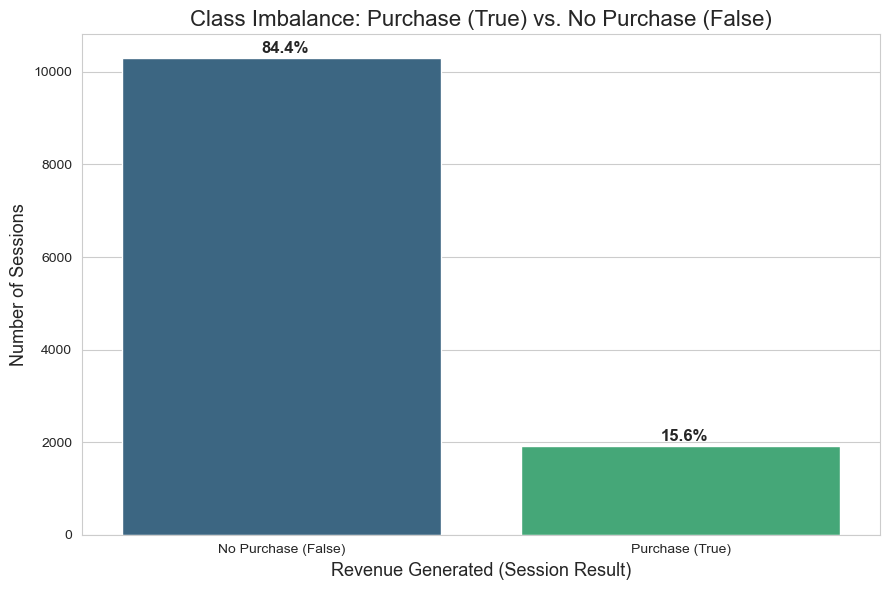

In [4]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
ax = sns.countplot(x='Revenue', data=df, palette='viridis')

total = len(df['Revenue'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + (total * 0.01) # Position text slightly above bar
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Class Imbalance: Purchase (True) vs. No Purchase (False)', fontsize=16)
plt.xlabel('Revenue Generated (Session Result)', fontsize=13)
plt.ylabel('Number of Sessions', fontsize=13)
plt.xticks([0, 1], ['No Purchase (False)', 'Purchase (True)'])

plt.tight_layout()
plt.show()

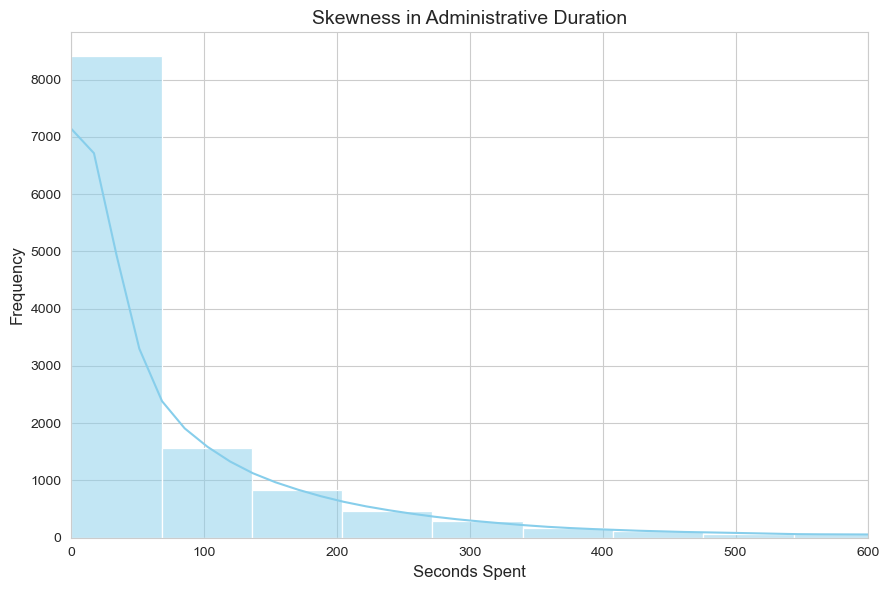

Skewness (Admin): 5.59
Mean (Admin): 81.65
Median (Admin): 9.00


In [5]:
plt.figure(figsize=(9, 6))
sns.histplot(df['Administrative_Duration'], bins=50, kde=True, color='skyblue')
plt.xlim(0, 600)
plt.title('Skewness in Administrative Duration', fontsize=14)
plt.xlabel('Seconds Spent', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Skewness (Admin): {df['Administrative_Duration'].skew():.2f}")

print(f"Mean (Admin): {mean_val_administrative:.2f}")
print(f"Median (Admin): {median_val_administrative:.2f}")

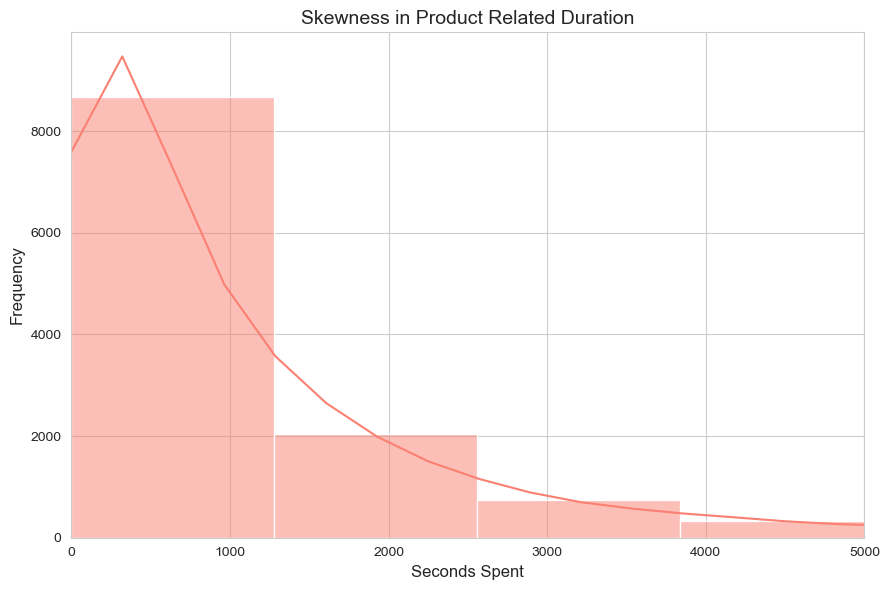

Skewness (Product): 7.25
Mean (Product): 1206.98
Median (Product): 608.94


In [6]:
plt.figure(figsize=(9, 6))
sns.histplot(df['ProductRelated_Duration'], bins=50, kde=True, color='salmon')
plt.xlim(0, 5000)
plt.title('Skewness in Product Related Duration', fontsize=14)
plt.xlabel('Seconds Spent', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Skewness (Product): {df['ProductRelated_Duration'].skew():.2f}")

print(f"Mean (Product): {mean_val_ProductRelated:.2f}")
print(f"Median (Product): {median_val_ProductRelated:.2f}")

In [7]:
df['Revenue'] = df['Revenue'].astype(int)

C:\Users\Garkjf\AppData\Local\Temp\ipykernel_31252\757649208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='magma')


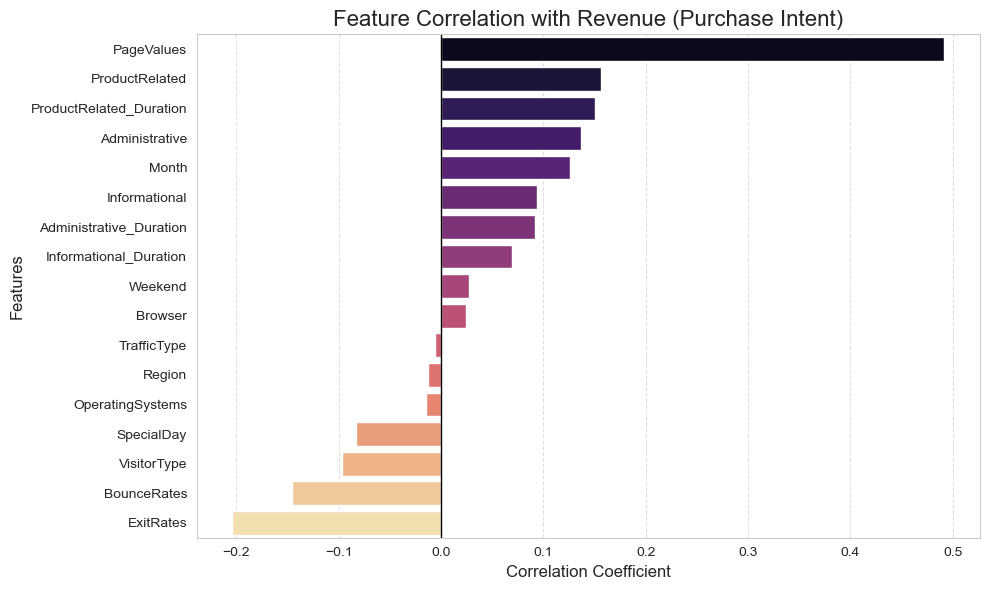

In [8]:
correlations = df.corr()['Revenue'].sort_values(ascending=False).drop('Revenue')

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='magma')

plt.title('Feature Correlation with Revenue (Purchase Intent)', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

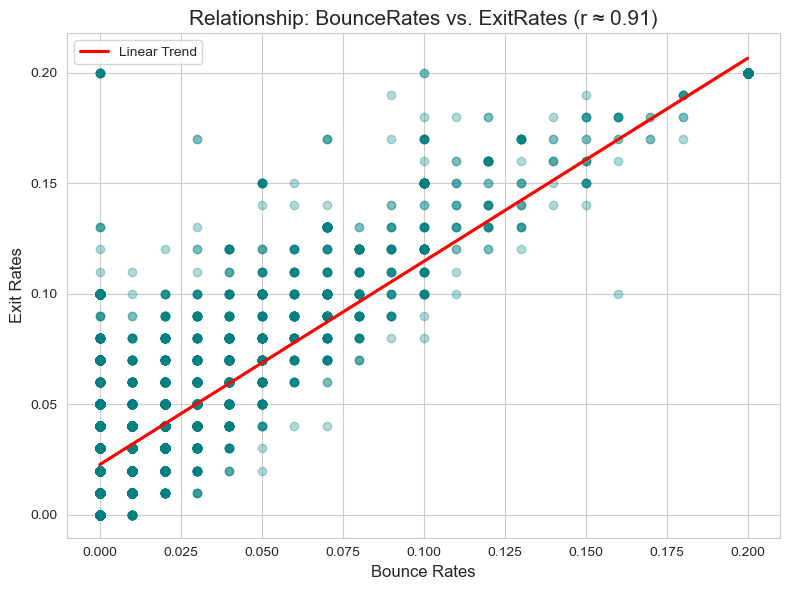

In [9]:
plt.figure(figsize=(8, 6))

sns.regplot(x='BounceRates', y='ExitRates', data=df, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Linear Trend'})

plt.title('Relationship: BounceRates vs. ExitRates (r ≈ 0.91)', fontsize=15)
plt.xlabel('Bounce Rates', fontsize=12)
plt.ylabel('Exit Rates', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
conversion_rates = df.groupby('VisitorType')['Revenue'].mean() * 100
conversion_rates = conversion_rates.reset_index()

C:\Users\Garkjf\AppData\Local\Temp\ipykernel_31252\557145022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='VisitorType', y='Revenue', data=conversion_rates, palette='Set2')


(0.0, 29.92616656822209)

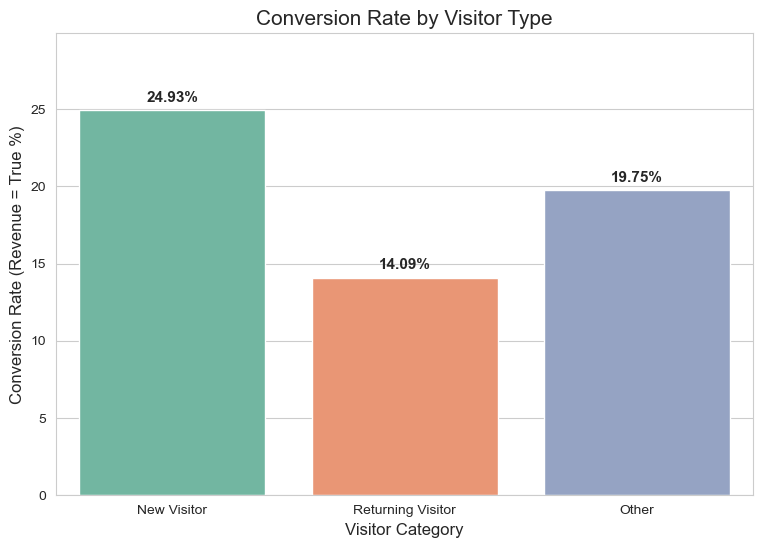

In [11]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='VisitorType', y='Revenue', data=conversion_rates, palette='Set2')

plt.xticks(ticks=[0, 1, 2], labels=['New Visitor', 'Returning Visitor', 'Other'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Conversion Rate by Visitor Type', fontsize=15)
plt.ylabel('Conversion Rate (Revenue = True %)', fontsize=12)
plt.xlabel('Visitor Category', fontsize=12)
plt.ylim(0, max(conversion_rates['Revenue']) + 5)

In [12]:
y_true = df['Revenue'].astype(int)
y_pred = np.zeros_like(y_true)

<Figure size 700x600 with 0 Axes>

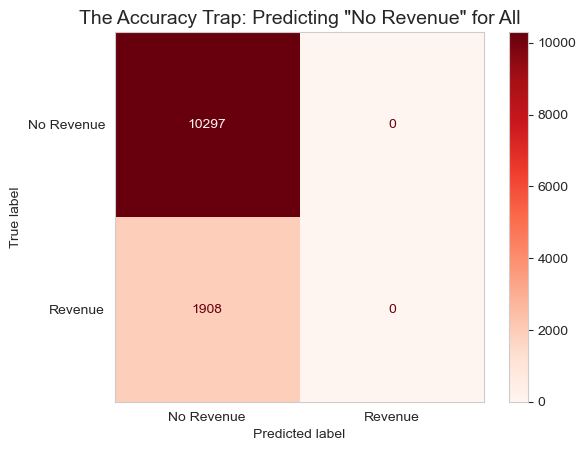

Model Accuracy: 84.4%
Notice: The model caught 0 actual purchases (Bottom-Right box is 0).


In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Revenue', 'Revenue'])
disp.plot(cmap='Reds', values_format='d')

plt.title('The Accuracy Trap: Predicting "No Revenue" for All', fontsize=14)
plt.grid(False) # Clean up the grid for the matrix
plt.show()

accuracy = (y_true == y_pred).mean() * 100
print(f"Model Accuracy: {accuracy:.1f}%")
print("Notice: The model caught 0 actual purchases (Bottom-Right box is 0).")

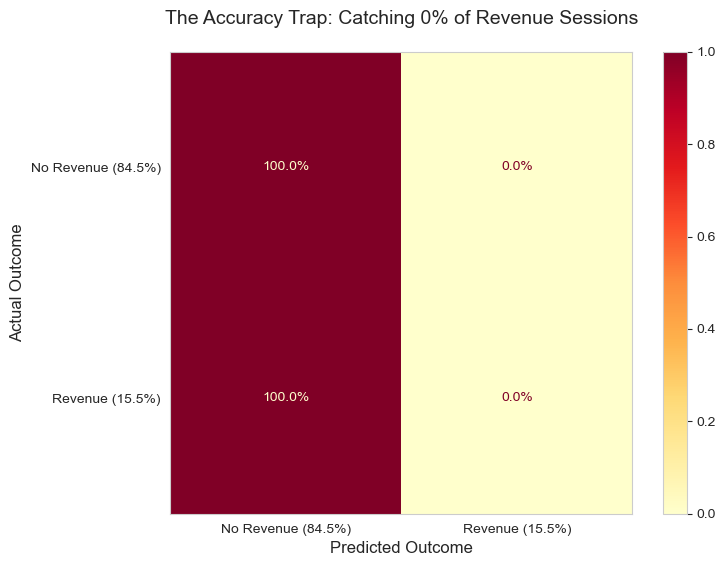

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Generate the confusion matrix normalized by 'true' (rows)
# This shows exactly what % of each class we are catching
cm_normalized = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, 
                              display_labels=['No Revenue (84.5%)', 'Revenue (15.5%)'])

disp.plot(cmap='YlOrRd', ax=ax, values_format='.1%')

plt.title('The Accuracy Trap: Catching 0% of Revenue Sessions', fontsize=14, pad=20)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('Actual Outcome', fontsize=12)
plt.grid(False)

plt.show()

In [26]:
models = ['MLP', 'Gen-AI MLP', 'RNN', 'Gen-AI RNN']
accuracy_scores = [0.8701, 0.8914, 0.8869, 0.8709]
recall_scores = [0.52, 0.54, 0.50, 0.71]

x = np.arange(len(models))  
width = 0.35  

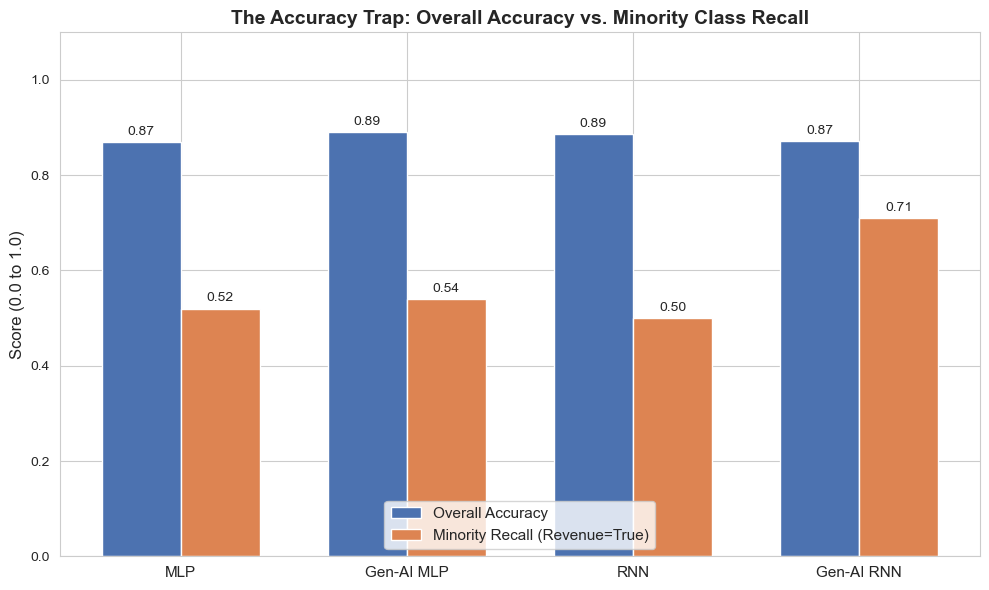

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Overall Accuracy', color='#4C72B0')
rects2 = ax.bar(x + width/2, recall_scores, width, label='Minority Recall (Revenue=True)', color='#DD8452')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('The Accuracy Trap: Overall Accuracy vs. Minority Class Recall', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower center', fontsize=11)

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()